<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Attention Inside a Trained Model</b>
</h1>
<div style="font-family:'Times New Roman';">
Notebook 02 used vectors i wrote by hand. Here attention is trained, on a task built so that there is exactly one correct place to look. Then i can check whether the attention weights actually point there, wich makes it a proper test and not just a nice picture.
</div>

## the task

each sequence has 20 steps and two channels:

- channel 0 : a random number at every step
- channel 1 : a marker, it is 1 at exactly one random position and 0 everywhere else

the model has to output the number that sits at the marked position. so the answer is one specific step and the other 19 are noise. if attention works, its weights should land on the marked step.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

def make_data(n, T=20, seed=0):
    g = torch.Generator().manual_seed(seed)
    values = torch.randn(n, T, generator=g)
    pos = torch.randint(0, T, (n,), generator=g)

    marker = torch.zeros(n, T)
    marker[torch.arange(n), pos] = 1.0

    x = torch.stack([values, marker], dim=2)        # (n, T, 2)
    y = values[torch.arange(n), pos]                 # the answer
    return x, y, pos

T = 20
x, y, pos       = make_data(2000, T, seed=1)
xt, yt, pos_t   = make_data(500,  T, seed=2)

print("input :", x.shape, " target :", y.shape)
print("first sequence, marker is at position", pos[0].item(), "so the answer is", round(y[0].item(), 3))

input : torch.Size([2000, 20, 2])  target : torch.Size([2000])
first sequence, marker is at position 3 so the answer is -1.609


## the model

as small as it can be:

1. project each step from 2 numbers to 32
2. score every step against one learnt query vector
3. softmax, weighted sum
4. one linear layer to the answer

the query is a single parameter, the model has to learn what to look for.

In [12]:
D = 32
proj  = nn.Linear(2, D)
query = nn.Parameter(torch.randn(D) * 0.1)
head  = nn.Linear(D, 1)

params = list(proj.parameters()) + [query] + list(head.parameters())
print("parameters :", sum(p.numel() for p in params))

def forward(x):
    h = torch.tanh(proj(x))                    # (n, T, D)
    scores = (h @ query) / D ** 0.5            # (n, T)
    weights = torch.softmax(scores, dim=1)
    context = (weights.unsqueeze(2) * h).sum(1)
    return head(context).squeeze(1), weights

parameters : 161


In [4]:
opt = torch.optim.Adam(params, lr=0.01)
hist = []

for epoch in range(600):
    pred, _ = forward(x)
    loss = ((pred - y) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    hist.append(loss.item())
    if epoch % 150 == 0:
        print("epoch", str(epoch).rjust(3), " loss", round(loss.item(), 5))

epoch   0  loss 1.02255


epoch 150  loss 0.00172


epoch 300  loss 0.00048


epoch 450  loss 0.00068


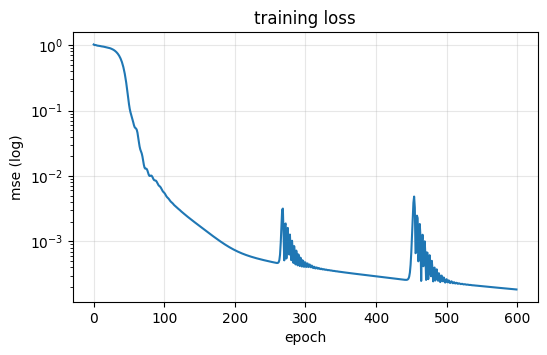

In [5]:
plt.figure(figsize=(6,3.5))
plt.semilogy(hist)
plt.xlabel('epoch'); plt.ylabel('mse (log)'); plt.grid(alpha=.3)
plt.title('training loss')
plt.show()

## is it right

In [6]:
with torch.no_grad():
    pred_t, w_t = forward(xt)

mse = ((pred_t - yt) ** 2).mean().item()
print("test mse           :", round(mse, 5))
print("variance of target :", round(yt.var().item(), 3), " (this is what guessing the mean would give)")

test mse           : 0.00011
variance of target : 0.863  (this is what guessing the mean would give)


## the real check, where is it looking

the attention weights can be compared against the marker position, so this is measurable and not a matter of opinion.

In [8]:
with torch.no_grad():
    picked = w_t.argmax(dim=1)
    acc = (picked == pos_t).float().mean().item()
    mass = w_t[torch.arange(len(pos_t)), pos_t].mean().item()

print("attention peak is on the marked step :", round(acc * 100, 1), "%")
print("average weight given to the marked step :", round(mass, 3))

attention peak is on the marked step : 100.0 %
average weight given to the marked step : 0.55


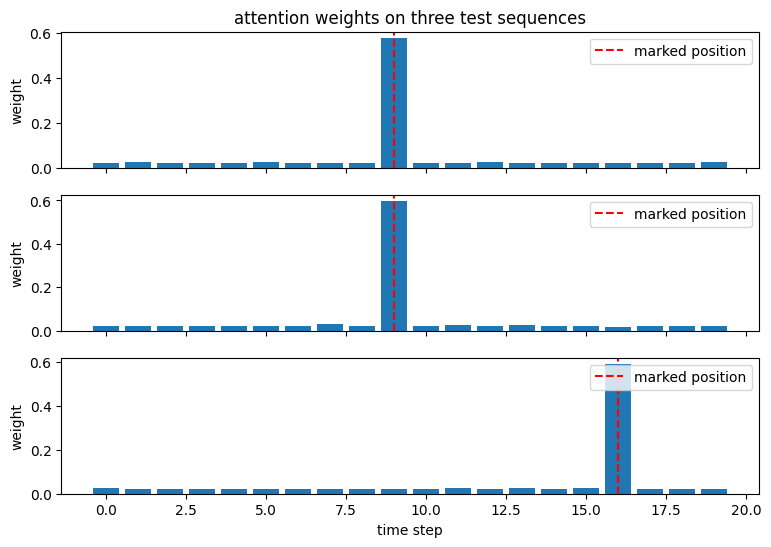

In [9]:
fig, ax = plt.subplots(3, 1, figsize=(9,6), sharex=True)
for i in range(3):
    ax[i].bar(range(T), w_t[i].numpy())
    ax[i].axvline(pos_t[i].item(), color='red', ls='--', label='marked position')
    ax[i].set_ylabel('weight'); ax[i].legend(loc='upper right')
ax[-1].set_xlabel('time step')
ax[0].set_title('attention weights on three test sequences')
plt.show()

the peak lands on the red line in every single test sequence, 100 percent. but the weight on the marked step is only 0.55 on average, not 1. the other half is spread thin across the remaining 19 steps, about 0.024 each. it does not need a perfectly sharp peak, it only needs the right step to dominate the average.

the model was never told where to look. it only ever saw whether its final number was right, and from that it worked out that the marker channel is the thing to search for.

## the control experiment

is attention really doing the work, or would anything have solved this? replacing attention with a plain average over the steps, everything else identical.

In [10]:
proj2 = nn.Linear(2, D)
head2 = nn.Linear(D, 1)
params2 = list(proj2.parameters()) + list(head2.parameters())

def forward_mean(x):
    h = torch.tanh(proj2(x))
    return head2(h.mean(dim=1)).squeeze(1)      # no selection, just average everything

opt2 = torch.optim.Adam(params2, lr=0.01)
for epoch in range(600):
    loss2 = ((forward_mean(x) - y) ** 2).mean()
    opt2.zero_grad(); loss2.backward(); opt2.step()

with torch.no_grad():
    mse_mean = ((forward_mean(xt) - yt) ** 2).mean().item()

print("with attention    :", round(mse, 5))
print("with mean pooling :", round(mse_mean, 5))
print("variance of target:", round(yt.var().item(), 3))

with attention    : 0.00011
with mean pooling : 0.01542
variance of target: 0.863


not the result i expected. i thought mean pooling would land near 0.863, the variance of the target, wich is what you get by ignoring the input and predicting the average. instead it got 0.0154.

so it is doing something. the marked step has both channels active and produces a distinctive activation, and even after averaging over 20 steps a scaled version of that survives. it is 140 times worse than attention but far from useless.

the honest conclusion is weaker than the one i was going to write. attention is much better here, not because averaging cannot see the marker at all, but because averaging dilutes it by a factor of 20 while attention pulls out that one step almost cleanly.

### recap

- the query is one learnt vector, the model figures out for itself what to look for
- attention peak was on the correct step in 100 percent of the test sequences, with about 55 percent of the weight there
- the mean pooling control got 0.0154 against 0.00011, so 140 times worse, but still better than guessing. selection helps a lot, it is not the only thing that works
- attention weights are readable, i can point at the picture and say why the model gave that answer. an lstm hidden state does not let you do that